In [3]:
%matplotlib widget

In [4]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [5]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     363   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        44   (2094, 964)   float32   


In [6]:
image_cut = image[49:149, 0:1890]
image_error_cut = image_error[49:149, 0:1890]

Text(0.5, 0, 'wavelenght')

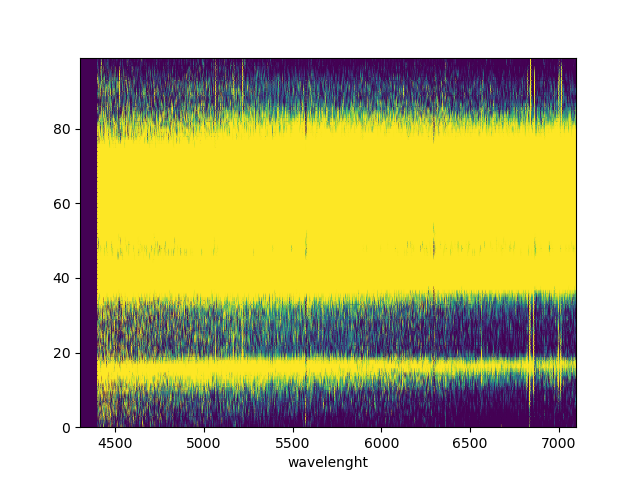

In [7]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [8]:
z = 0.04263
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII_1 = 6548 * (1+z) 
l_NII_2 = 6583 * (1+z)
l_SII_1 = 6717 * (1+z)
l_SII_2 = 6731 * (1+z)
l_OIII_1 = 4959 * (1+z)
l_OIII_2 = 5007 * (1+z)

Text(0.5, 1.0, 'H$\\alpha$')

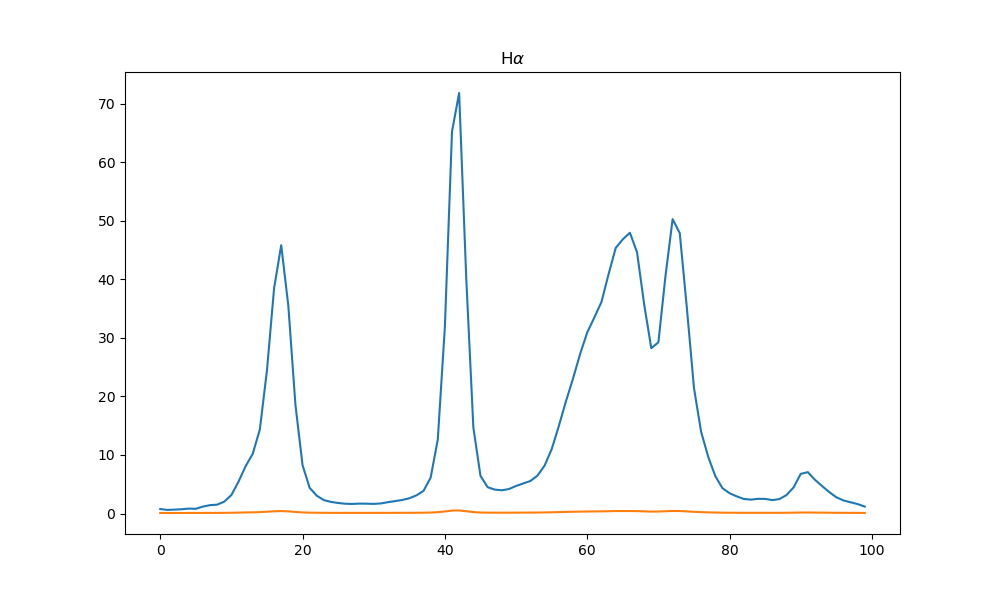

In [9]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')
#fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Fit_code/Halpha_fit.csv", index_col=0)

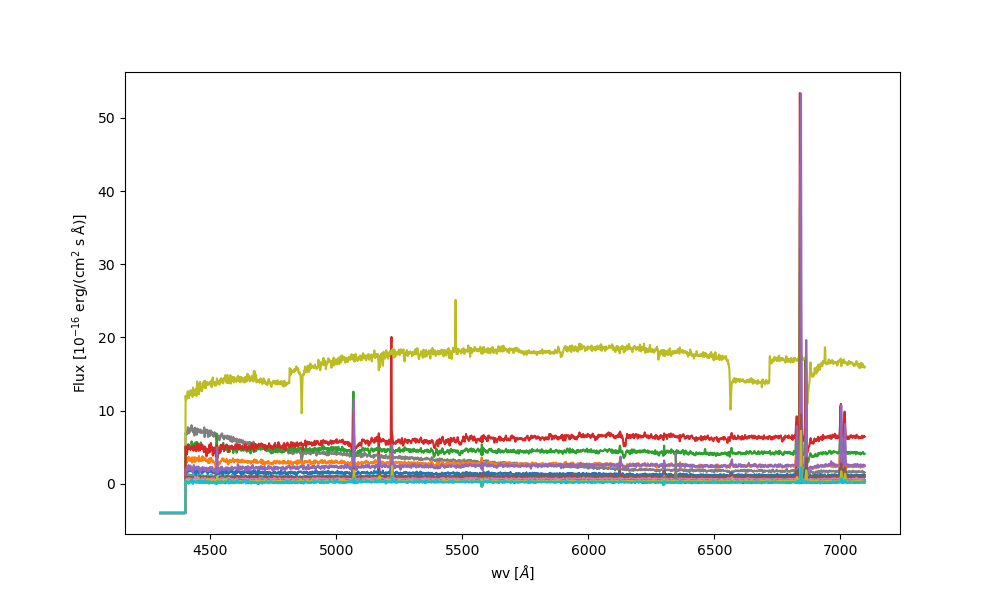

In [10]:
def extraction(x_axes, x_min, x_max, image_cut, image_error_cut):
    mask = (x_axes > x_min)*(x_axes < x_max)
    spectrum = np.sum(image_cut[mask, :], axis = 0)
    spectrum_err = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0))
    return spectrum, spectrum_err

os.makedirs('20ext', exist_ok=True)

spectra =  np.zeros((20, image_cut.shape[1]))
spectra_err = np.zeros((20, image_error_cut.shape[1]))
plt.figure(figsize=(10, 6))
for i in range(20):
    x_min = i * 5
    x_max = x_min + 5
    spectra[i], spectra_err[i] = extraction(x_axes, x_min, x_max, image_cut, image_error_cut)

    plt.plot(wv, spectra[i], label = f'spectrum {i+1}')
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra[i].reshape(-1, 1), spectra_err[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('20ext', f'Spectrum_{i+1}.txt')  # Salva come spectrum_1.txt ... spectrum_20.txt
    np.savetxt(filename, spectrum_table)

## S/N continuum

In [11]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
mask_continuum_2 = (wv > 5300)*(wv < 5800)
mask_continuum_3 = (wv > 6400)*(wv < 6700)
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []
# Calcolo per ogni spettro
for i in range(20):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra[i, mask_continuum_1])
    noise_1 = np.std(spectra[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra[i, mask_continuum_2])
    noise_2 = np.std(spectra[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra[i, mask_continuum_3])
    noise_3 = np.std(spectra[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)
    
# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(20)]
# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)
print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)
# Salvataggio dei file
os.path.join('20ext', 'SNR_20ext_continuum.csv')
df_path_snr = os.path.join('20ext', 'SNR_20ext_continuum.csv')
df_path_signal = os.path.join('20ext', 'Signal_20ext_continuum.csv')
df_path_noise = os.path.join('20ext', 'Noise_20ext_continuum.csv')
df_path_combined = os.path.join('20ext', 'Combined_20ext_continuum.csv')
# Assicurati che la directory esista
os.makedirs('20ext', exist_ok=True)
df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')
print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5  \
Continuum_1    2.304343    3.815022    3.181150    2.139725    3.770528   
Continuum_2    3.229245    4.973629    7.556071    8.669576    4.958426   
Continuum_3    4.205652    4.772148    7.042675    5.740197    5.128512   

             Spectrum_6  Spectrum_7  Spectrum_8  Spectrum_9  Spectrum_10  \
Continuum_1    3.929480    5.288167    7.466569   36.419162     7.154244   
Continuum_2    5.407736    6.603222   10.922485   33.323925    10.323309   
Continuum_3    6.078325    7.895948   17.603316    8.658942    13.315779   

             Spectrum_11  Spectrum_12  Spectrum_13  Spectrum_14  Spectrum_15  \
Continuum_1     9.631573    12.926339    13.205739    14.803562     6.870009   
Continuum_2    13.724289    18.863851    21.986047    18.901970    17.088270   
Continuum_3    14.939981    19.151579    25.544142    31.925998    17.351327   

             Spectrum_16  Spectrum_17  Spectrum_18  Spectr

## Redshift

In [12]:
from astropy.modeling import models
import astropy.units as u
from specutils import Spectrum
import astropy.units as u
from specutils.fitting import find_lines_threshold, fit_generic_continuum
from specutils.manipulation import noise_region_uncertainty
from astropy.nddata import StdDevUncertainty
from astropy.modeling.fitting import LinearLSQFitter

Spettro 1
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 13
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
 4475.379999999948   emission                16
 4657.419999999895   emission               139
 6838.939999999251   emission              1613
6976.5799999992105   emission              1706
 4689.979999999885 absorption               161
 4765.459999999863 absorption               212
 4836.499999999842 absorption               260
 4860.179999999835 absorption               276
  5351.53999999969 absorption               608
 5579.459999999623 absorption               762
 5706.739999999585 absorption               848
 6297.259999999411 absorption              1247
 6408.259999999378 absorption              1322
Spettro 2
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 15
   line_center    line_type  line_center_index
     Angstrom                                


If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]


Spettro 10
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 9
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
 5218.339999999729   emission               518
  6300.21999999941   emission              1249
 6838.939999999251   emission              1613
6861.1399999992445   emission              1628
 6998.779999999204   emission              1721
  4740.29999999987 absorption               195
 6297.259999999411 absorption              1247
 6303.179999999409 absorption              1251
 6867.059999999243 absorption              1632
Spettro 11
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 15
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
 5065.899999999774   emission               415
  5216.85999999973   emission               517
  6300.21999999941   emission              

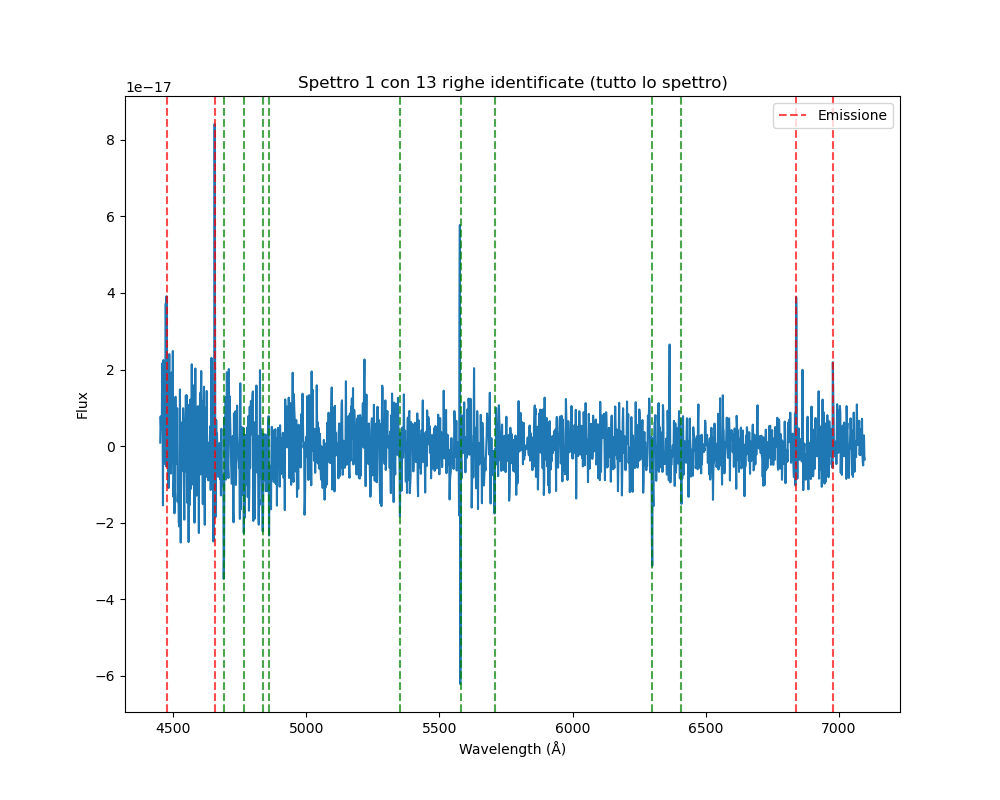

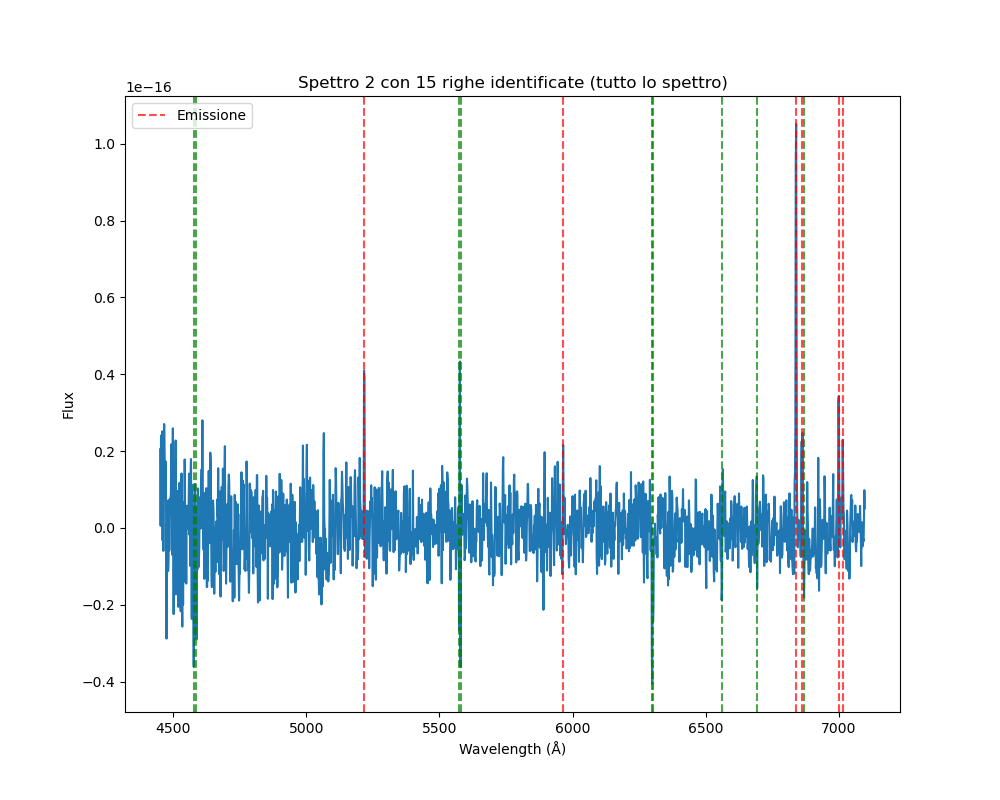

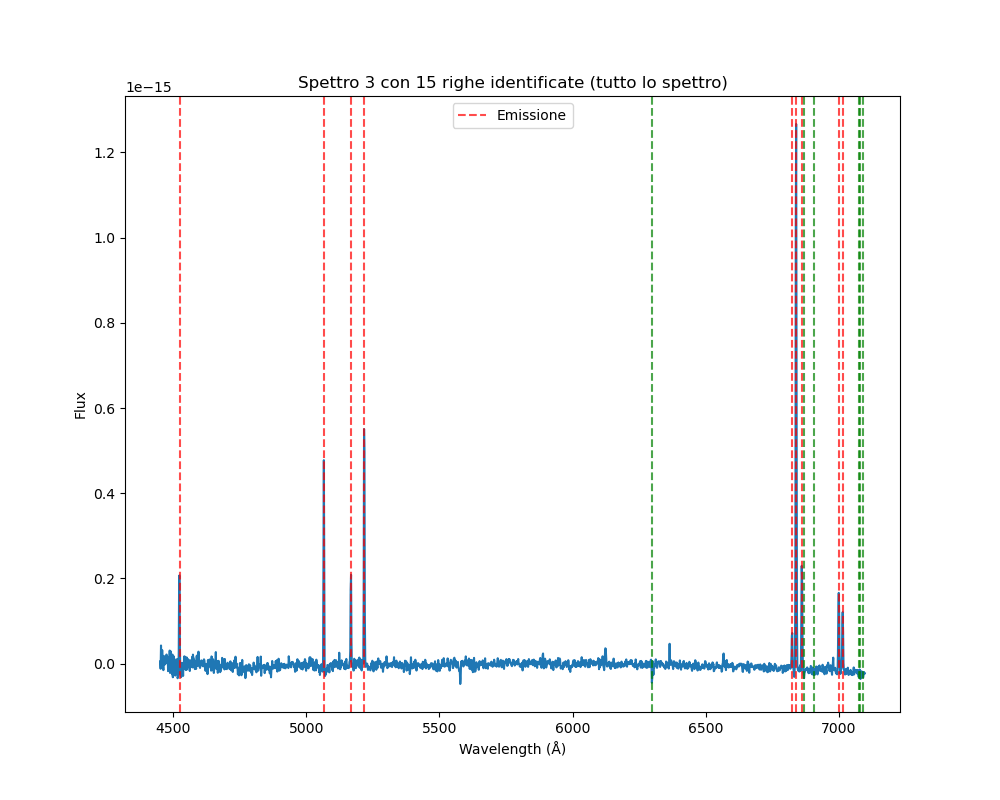

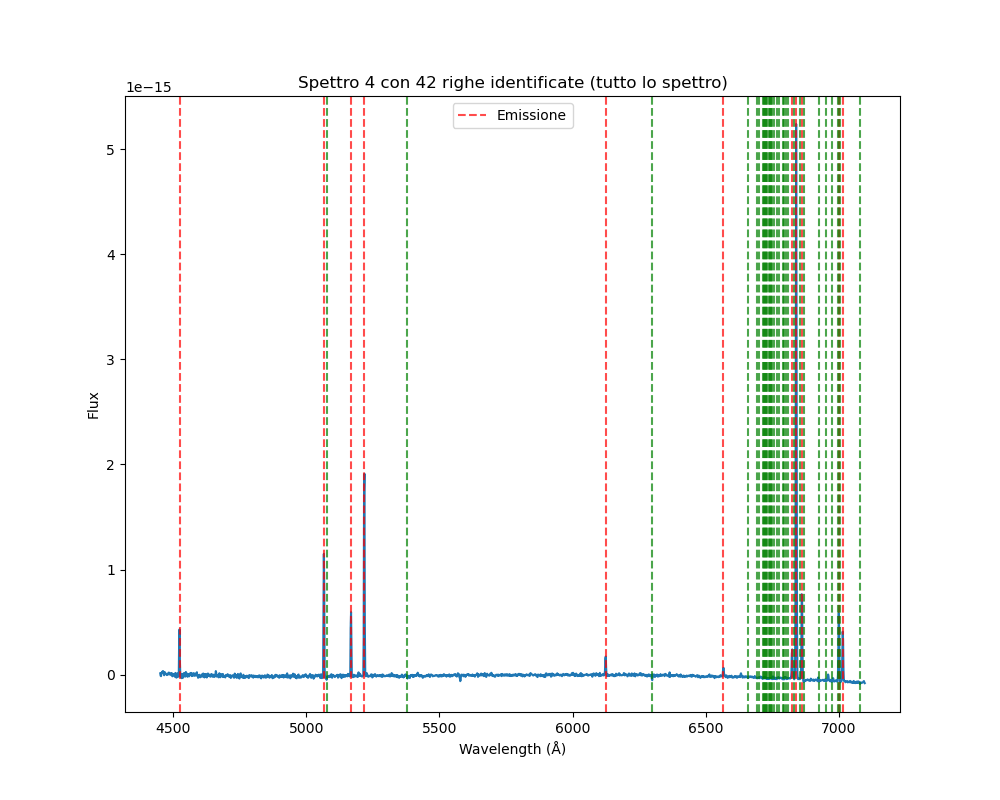

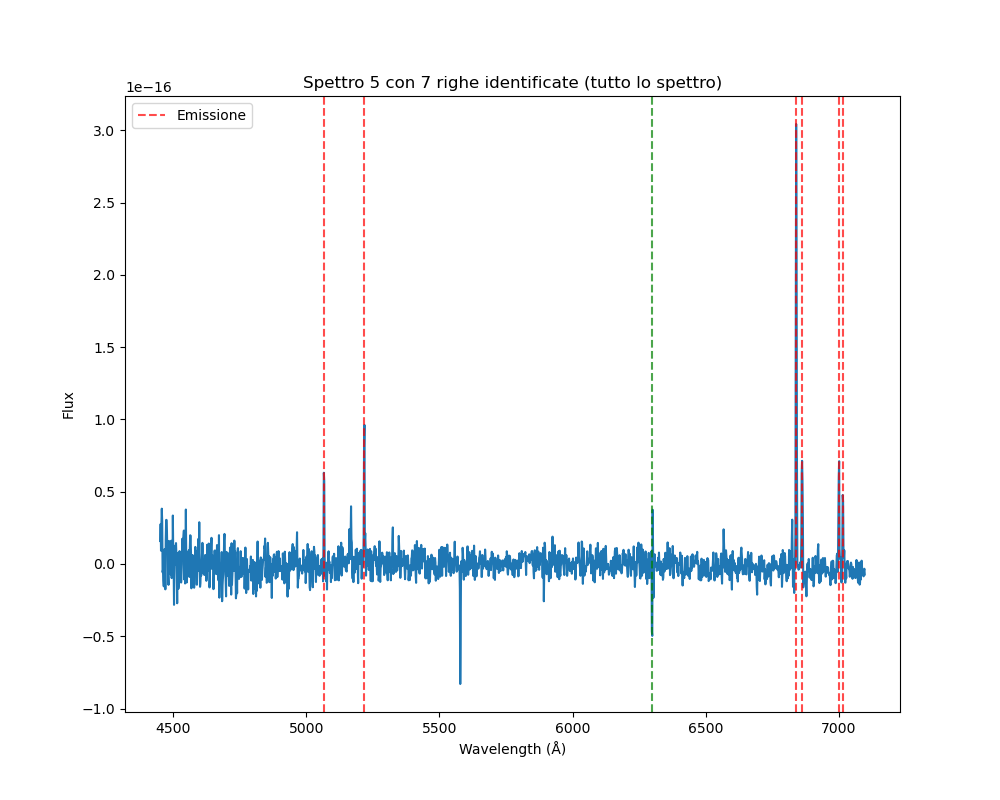

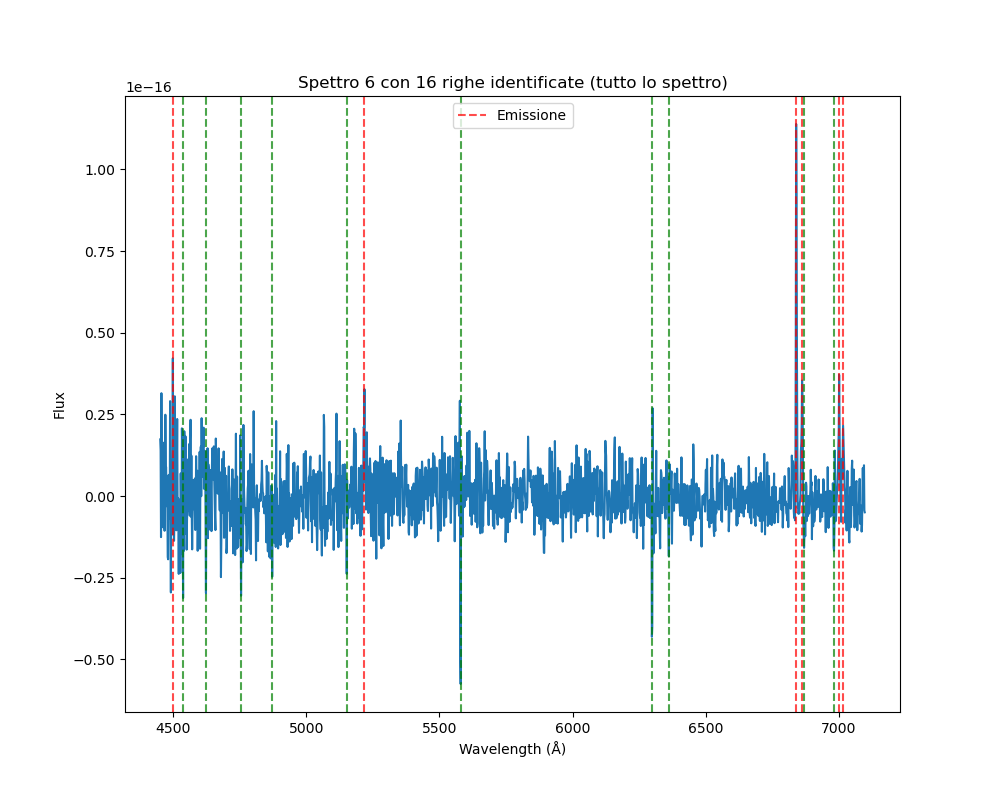

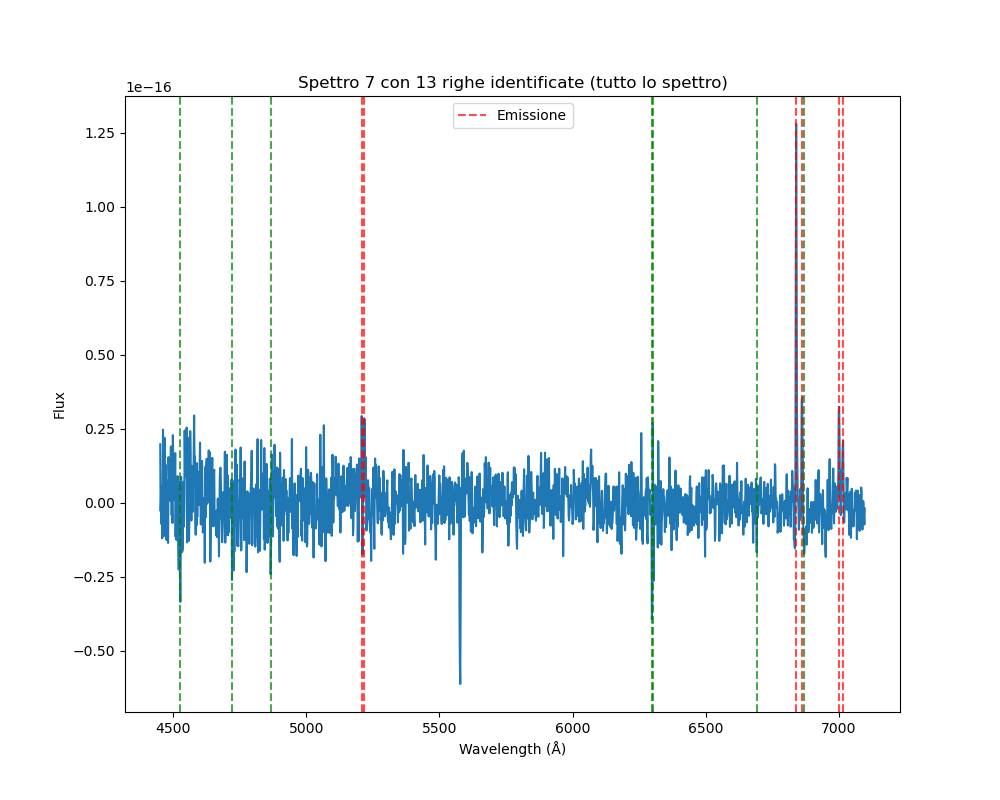

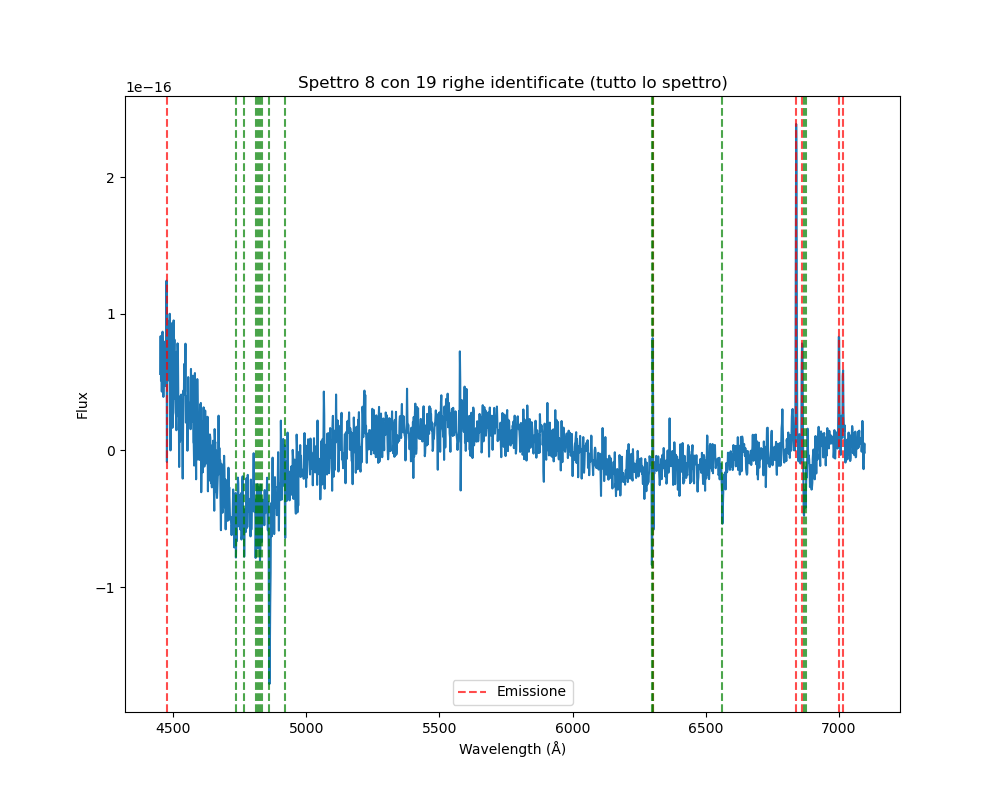

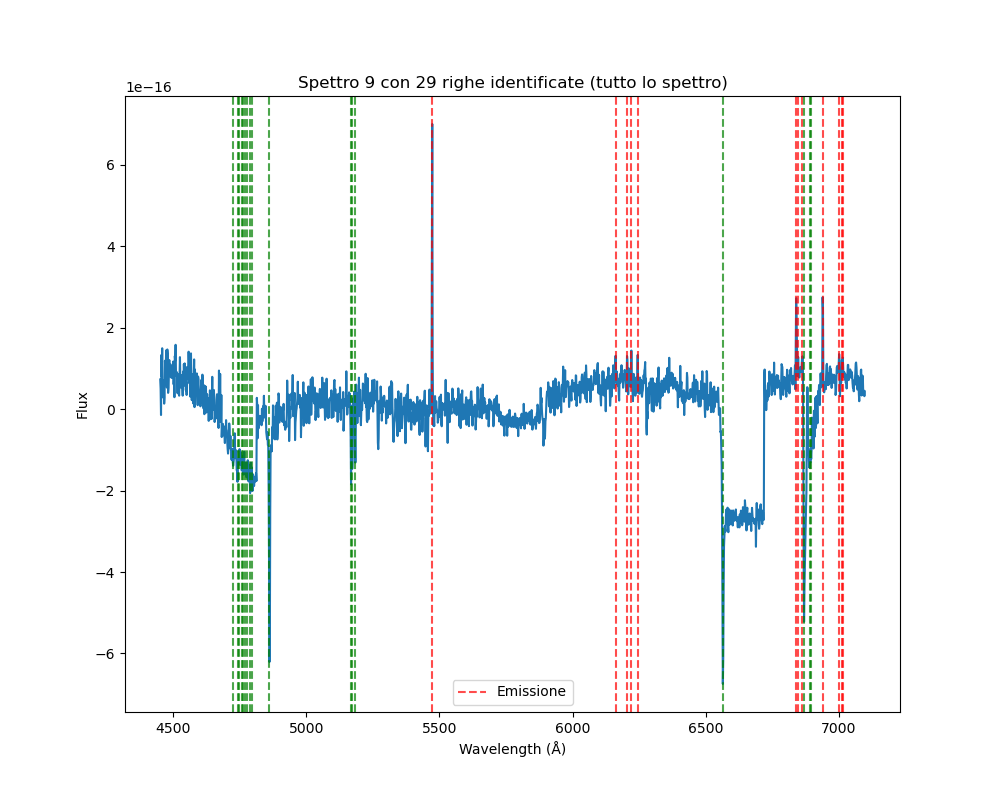

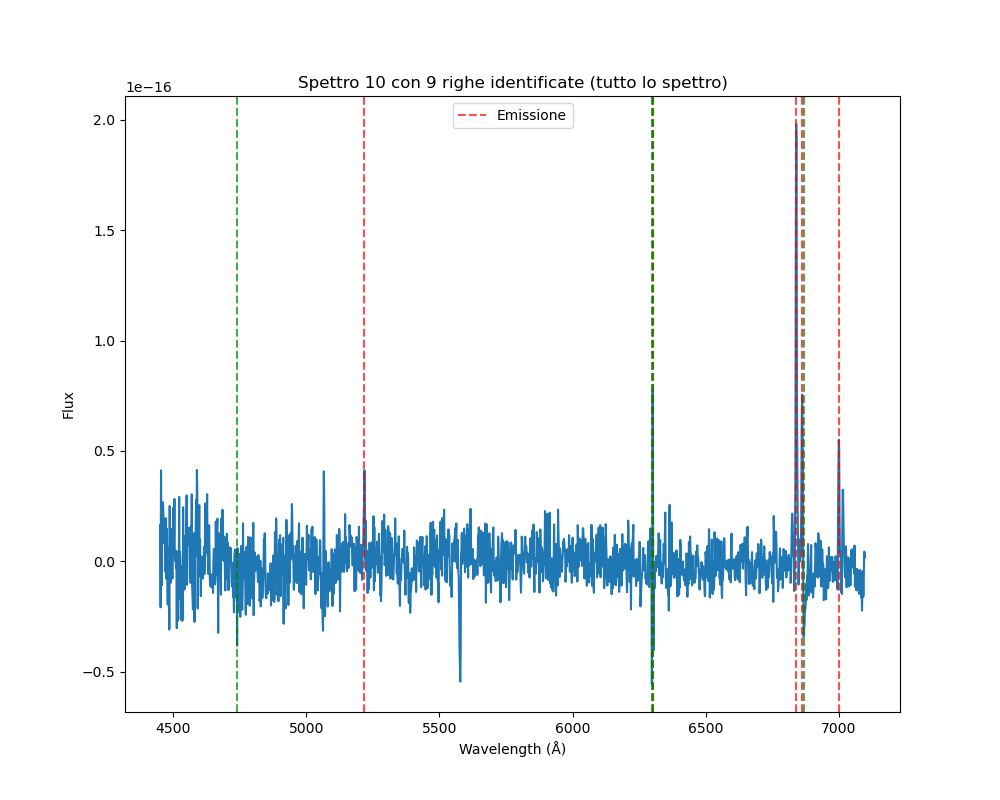

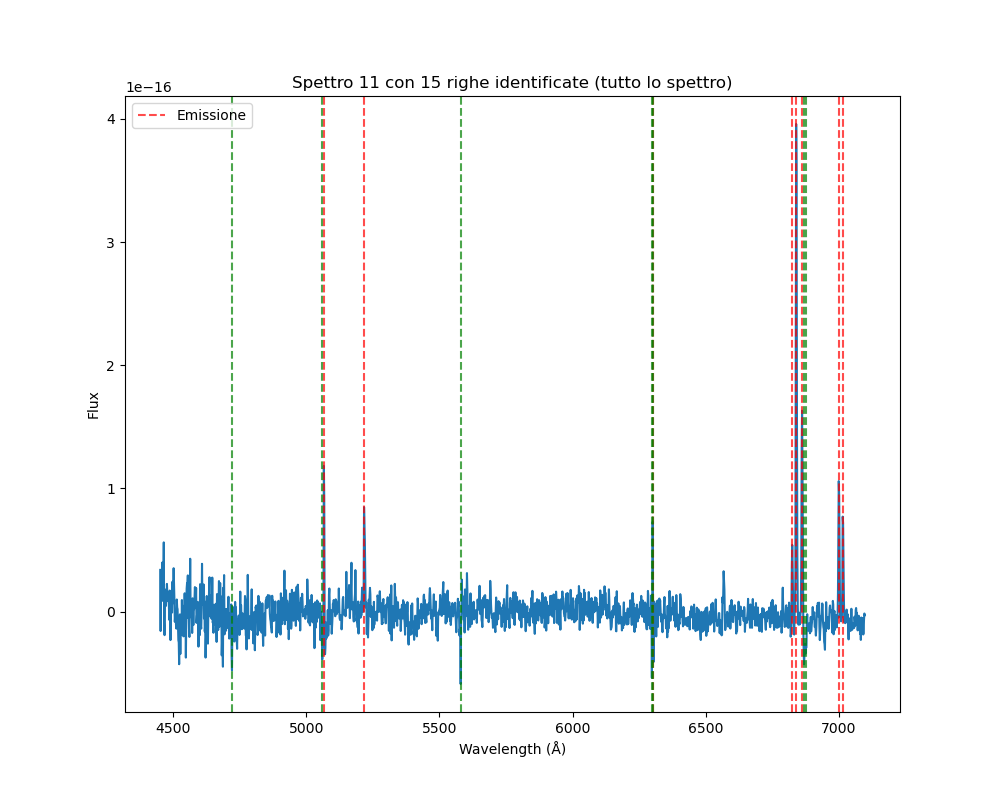

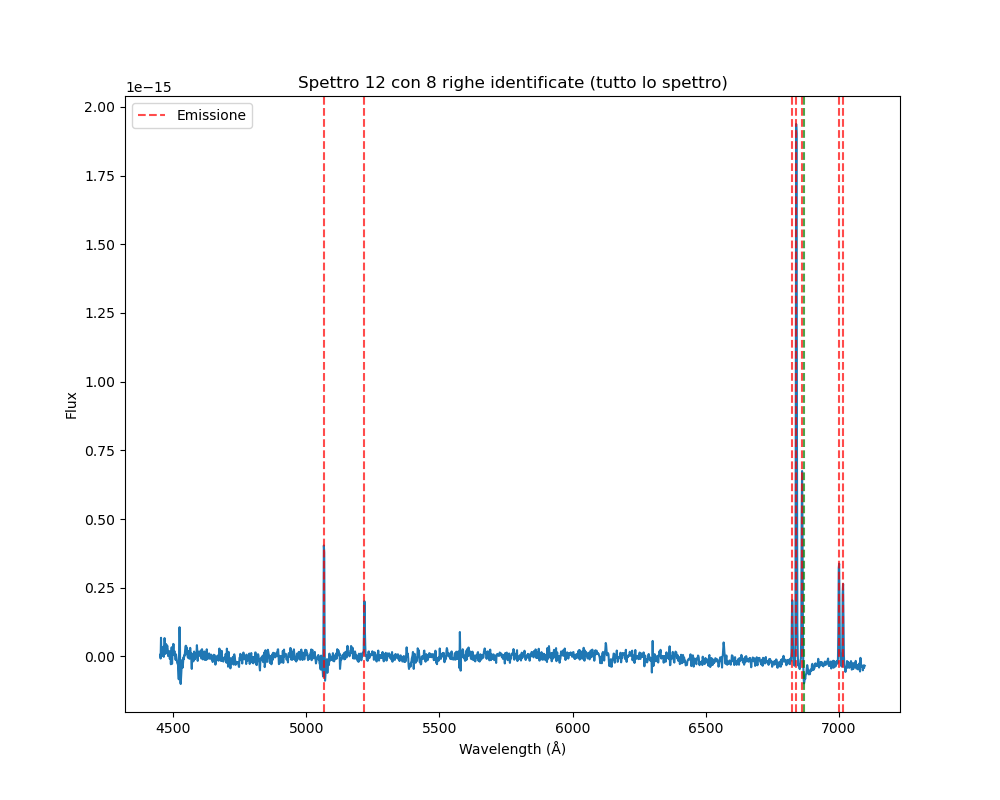

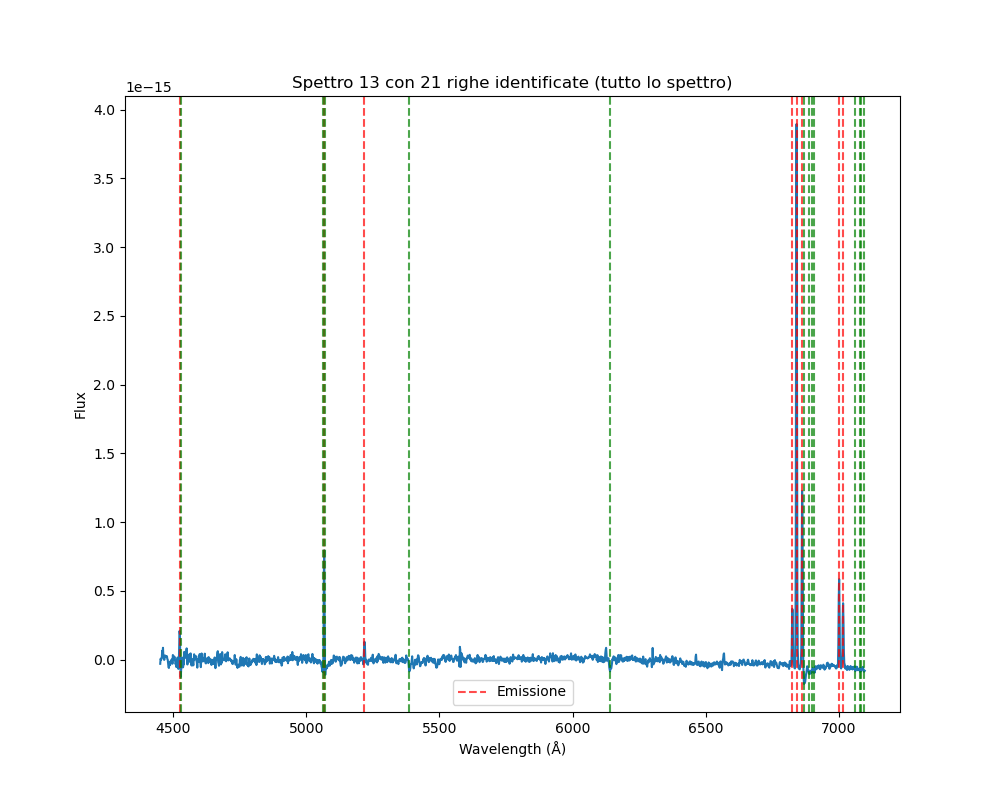

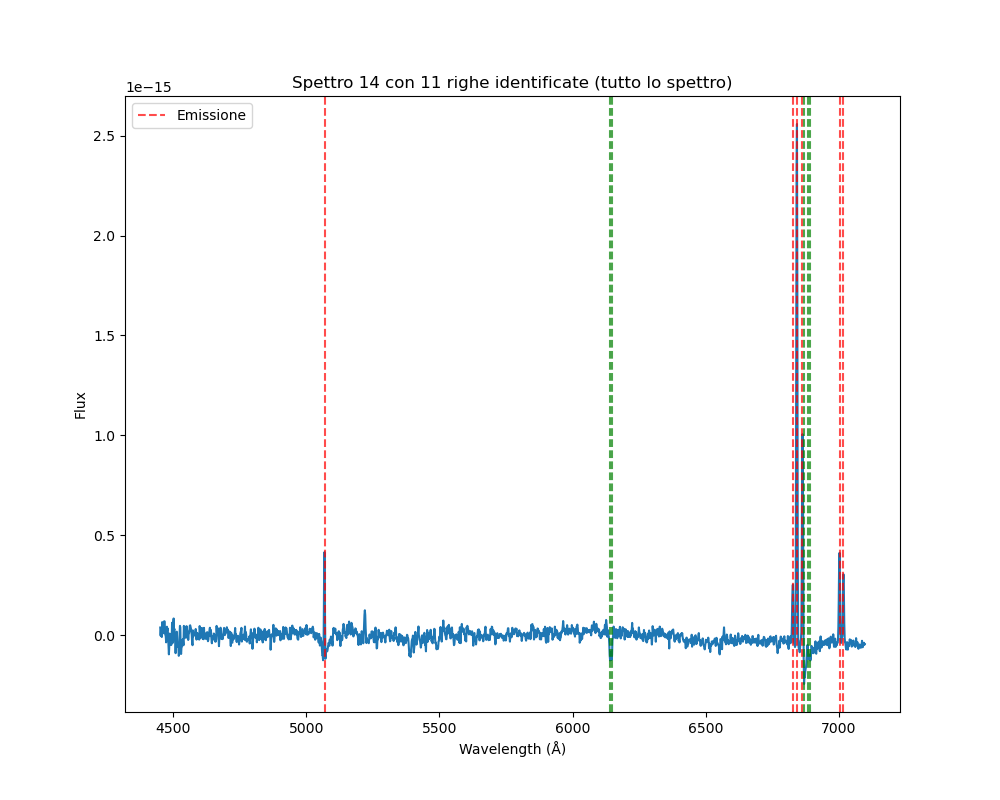

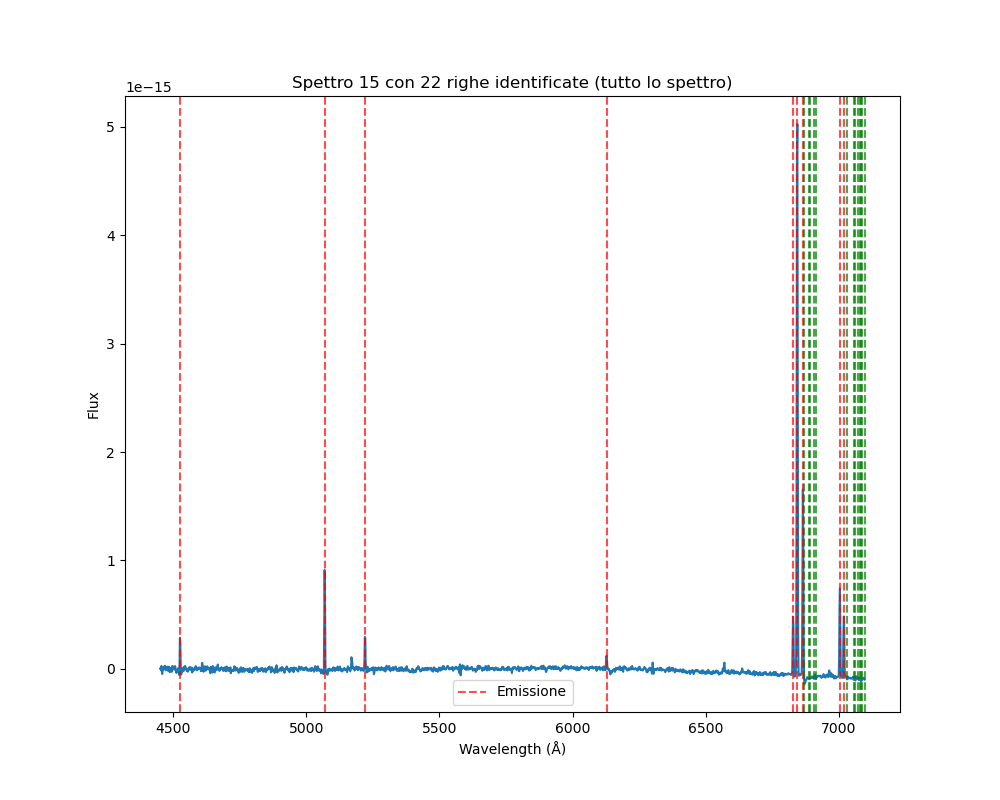

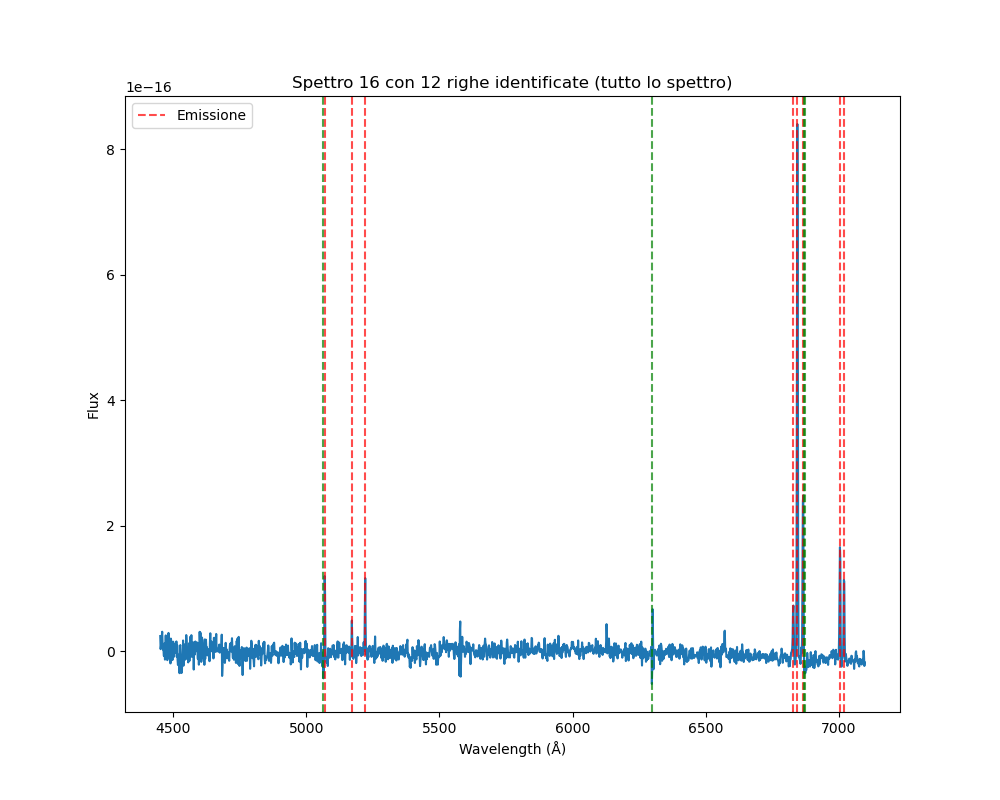

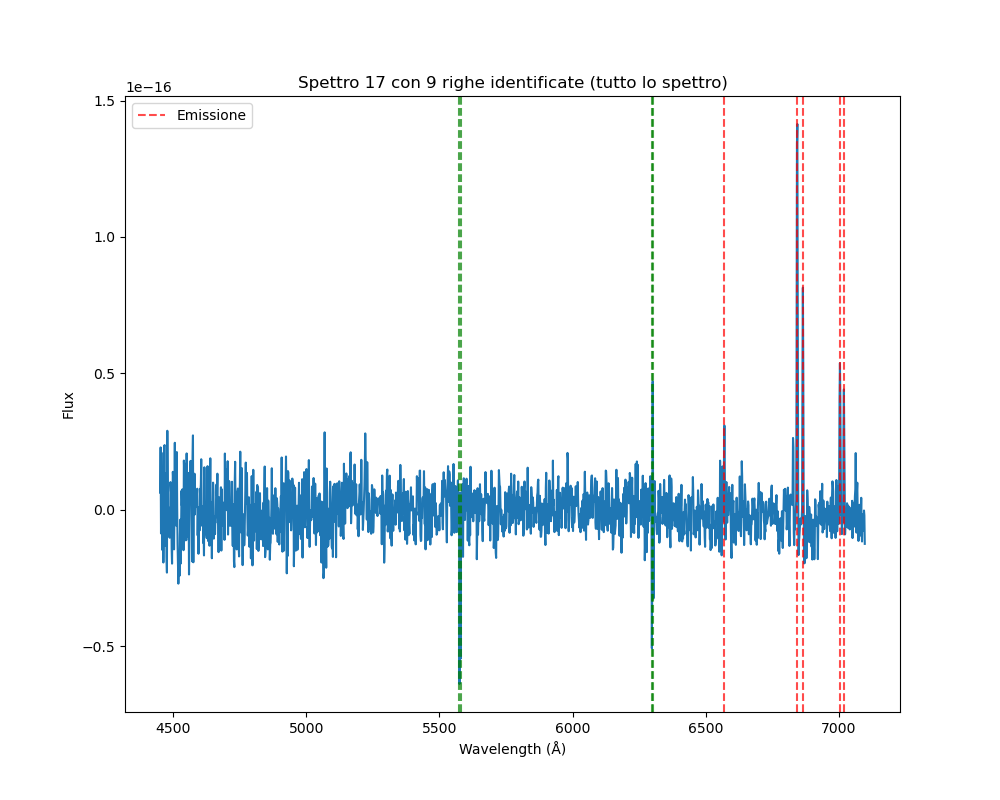

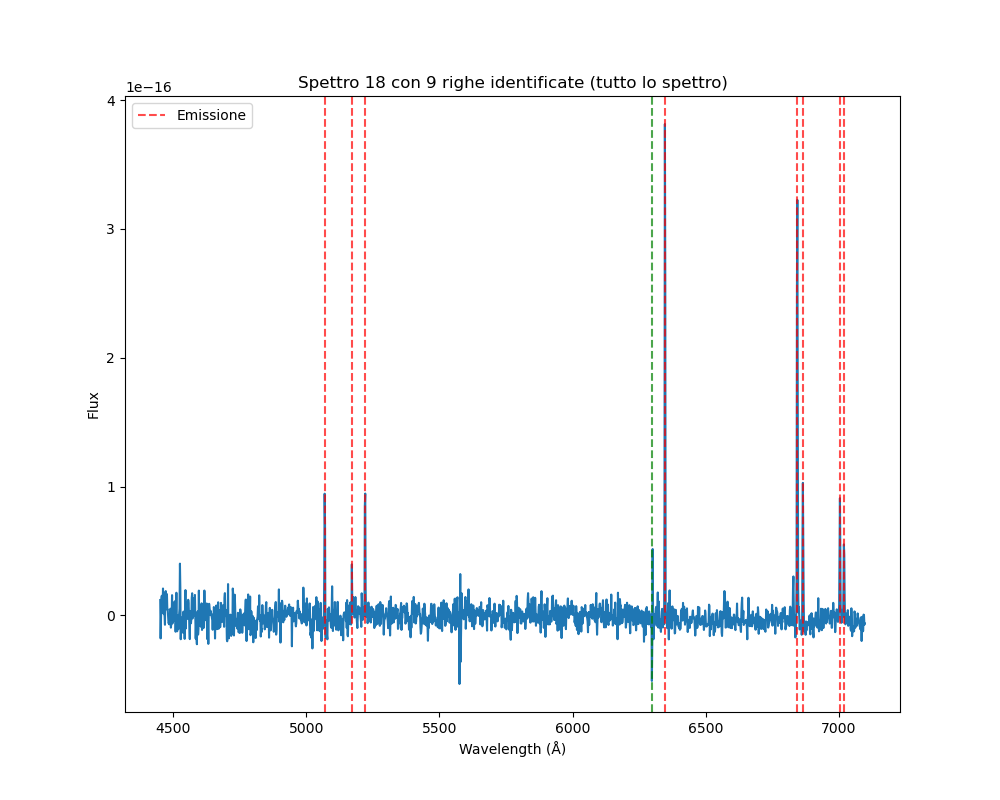

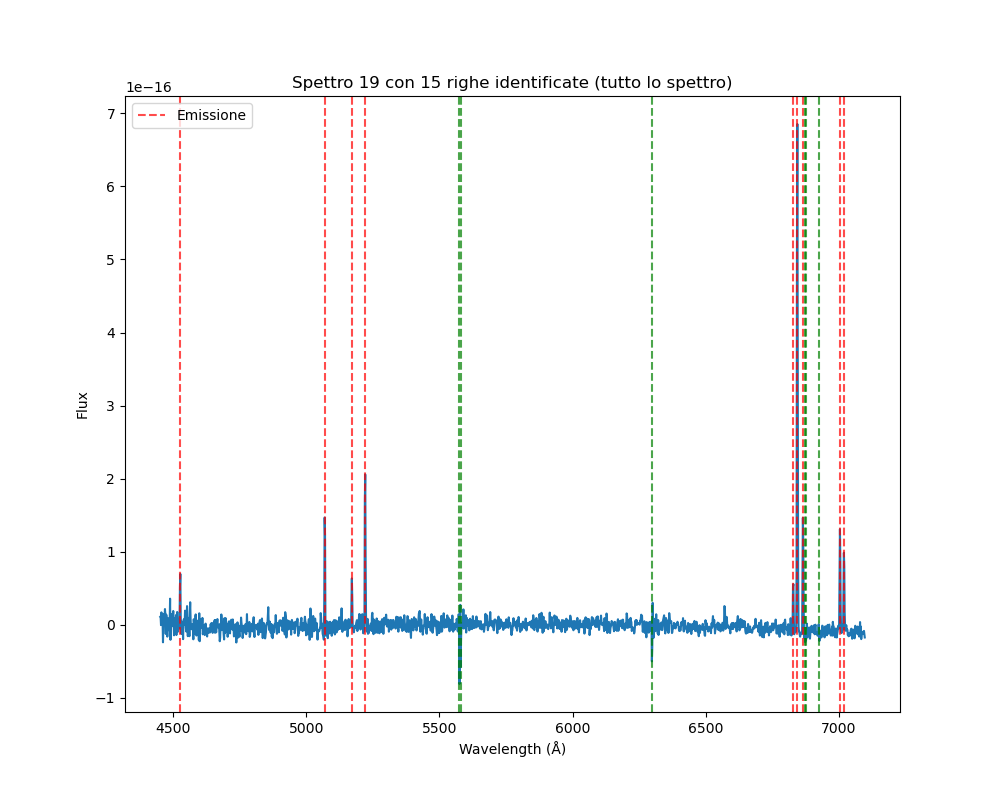

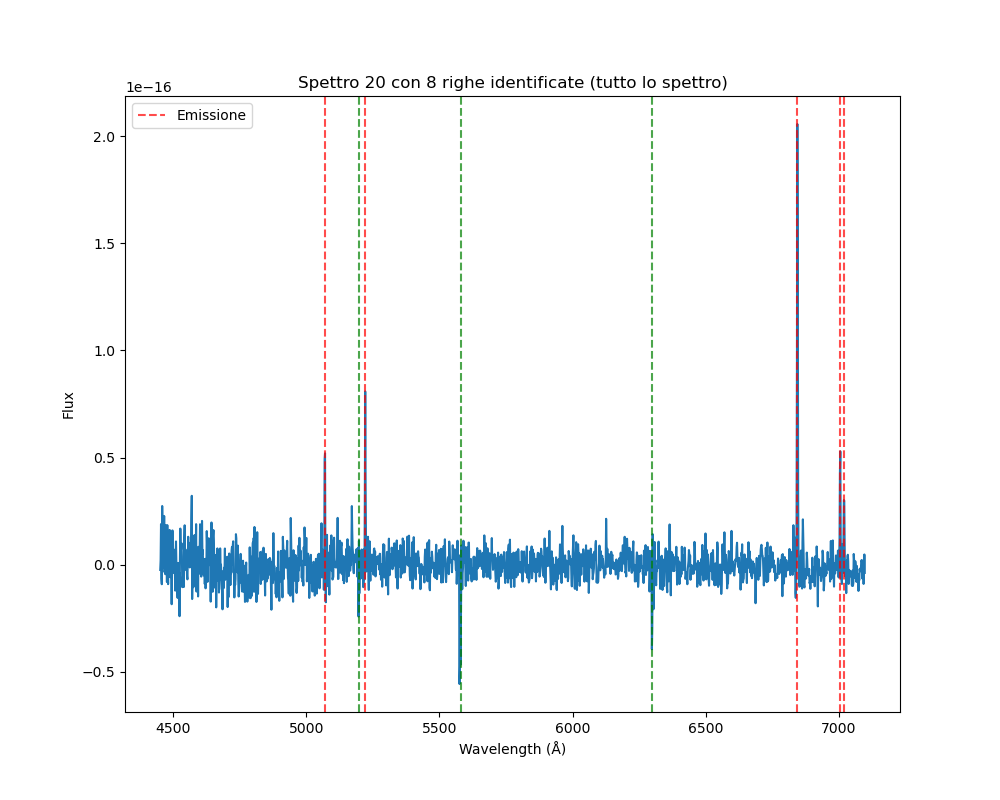

In [19]:
all_lines = []
noise_factor = [3, 3, 5, 5, 5, 3, 3, 4, 4.5, 4, 4, 8, 6, 8, 9, 5, 4, 4, 4, 4]
# Filtra per lunghezze d'onda > 4451 Å
wv_mask = wv > 4451
wv_filtered = wv[wv_mask]

for i in range(20):
    # Applica il filtro anche agli spettri
    spectra_filtered = spectra[i][wv_mask]
    spectra_err_filtered = spectra_err[i][wv_mask]
    
    # Usa lo spettro filtrato per il fitting del continuum
    spectrum = Spectrum(
        spectral_axis=wv_filtered * u.Angstrom,
        flux = spectra_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom),  
        uncertainty = StdDevUncertainty(spectra_err_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    g1_fit = fit_generic_continuum(spectrum, fitter=LinearLSQFitter())
    y_continuum_fitted = g1_fit(wv_filtered * u.Angstrom)
    
    flux_continuum_subtracted = spectrum.flux - y_continuum_fitted
    
    # Crea lo spettro per TUTTO il range filtrato (senza ritagliare i bordi)
    spectrum_no_continuum_full = Spectrum(
        spectral_axis=wv_filtered * u.Angstrom,
        flux=flux_continuum_subtracted,
        uncertainty=StdDevUncertainty(spectra_err_filtered * 1e-16 * u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    # Trova le righe su TUTTO lo spettro filtrato (senza escludere i bordi)
    lines = find_lines_threshold(spectrum_no_continuum_full, noise_factor = noise_factor[i])
    print('Spettro', i+1)
    print(f"Numero di righe trovate (tutto lo spettro, wv > 4451 Å): {len(lines)}")
    print(lines)
    
    f3, ax3 = plt.subplots(figsize=(10,8))
    ax3.plot(wv_filtered, flux_continuum_subtracted.value)
    
    if len(lines) < 50:  # Solo se non sono troppe
        for line_pos in lines['line_center']:
            # Trova l'indice corrispondente nel flux per determinare il tipo di riga
            line_idx = np.argmin(np.abs(wv_filtered - line_pos.value))
            
            # Determina se è emissione (positiva) o assorbimento (negativa)
            if flux_continuum_subtracted[line_idx].value > 0:
                # Riga di emissione - colore rosso
                ax3.axvline(x=line_pos.value, color='red', alpha=0.7, linestyle='--', 
                           label='Emissione' if line_pos == lines['line_center'][0] else "")
            else:
                # Riga di assorbimento - colore verde
                ax3.axvline(x=line_pos.value, color='green', alpha=0.7, linestyle='--',
                           label='Assorbimento' if line_pos == lines['line_center'][0] else "")
    
    ax3.legend()
    ax3.set_title(f"Spettro {i+1} con {len(lines)} righe identificate (tutto lo spettro)")
    ax3.set_xlabel('Wavelength (Å)')
    ax3.set_ylabel('Flux')
    all_lines.append(lines)

In [40]:
#reference wv in air
l_Hgam = 4340.5
l_HA = 6562.8
l_HB = 4861.3
l_NII_1 = 6548.1
l_NII_2 = 6583.4
l_SII_1 = 6717.0
l_SII_2 = 6731.3
l_OIII_1 = 4958.9
l_OIII_2 = 5006.8
l_He_1 = 5875.6
l_OI = 6300.3

lines_1 = [l_HA, l_NII_2]
lines_2 = [l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_3 = [l_HA, l_NII_2, l_SII_1]
lines_4 = [l_HA, l_NII_2, l_SII_1]
lines_5 = [l_HB, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_6 = [l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_7 = [l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_8 = [l_HA, l_NII_2, l_SII_1, l_SII_2]
#lines_9 = [l_HB, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_10 = [l_OIII_2, l_HA, l_NII_2, l_SII_1]
lines_11 = [l_HB, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_12 = [l_HB, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2] 
lines_13 = [l_Hgam, l_HB, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_14 = [l_HB, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_15 = [l_Hgam, l_HB, l_OIII_2, l_He_1, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_16 = [l_HB, l_OIII_1, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_17 = [l_OI, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_18 = [l_HB, l_OIII_1, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_19 = [l_Hgam, l_HB, l_OIII_1, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_20 = [l_HB, l_OIII_2, l_HA, l_SII_1, l_SII_2] 

lines_spectrum_1 = [6838.939999999251, 6862.62]
lines_spectrum_2 = [5216.85999999973, 6838.939999999251, 6859.659999999245, 6998.779999999204, 7013.5799999992]
lines_spectrum_3 = [6841.89999999925, 6862.619999999244, 7003.219999999203] 
lines_spectrum_4 = [6843.37999999925, 6862.619999999244, 7003.219999999203]
lines_spectrum_5 = all_lines[4]['line_center'] 
lines_spectrum_6 = [5218.339999999729, 6838.939999999251, 6861.1399999992445, 7000.2599999992035, 7015.059999999199]
lines_spectrum_7 = [5218.339999999729,  6838.939999999251, 6861.1399999992445, 7000.2599999992035,  7015.059999999199]
lines_spectrum_8 = [6838.939999999251, 6861.1399999992445, 6998.779999999204, 7015.059999999199]
#lines_spectrum_9 = all_lines[8]['line_center'] 
lines_spectrum_10 = [5218.339999999729, 6838.939999999251,6861.1399999992445, 6998.779999999204]
lines_spectrum_11 = [5065.899999999774, 5216.85999999973, 6824.139999999255, 6838.939999999251, 6861.1399999992445, 6998.779999999204, 7013.5799999992]
lines_spectrum_12 = all_lines[11]['line_center']
lines_spectrum_13 = all_lines[12]['line_center']
lines_spectrum_14 = all_lines[13]['line_center']
lines_spectrum_15 = all_lines[14]['line_center']
lines_spectrum_16 = all_lines[15]['line_center']
lines_spectrum_17 = all_lines[16]['line_center']
lines_spectrum_18 = [5068.859999999773, 5170.979999999743,  5221.299999999728,   6843.37999999925,  6864.099999999244,  7003.219999999203,  7018.019999999198]
lines_spectrum_19 = all_lines[18]['line_center']
lines_spectrum_20 = all_lines[19]['line_center']

def redshift(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i].value / lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std
    
def redshift_hand(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i]/ lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std
    
z_1_mean, z_1_std = redshift_hand(lines_1, lines_spectrum_1)    
z_2_mean, z_2_std = redshift_hand(lines_2, lines_spectrum_2)    
z_3_mean, z_3_std = redshift_hand(lines_3, lines_spectrum_3)    
z_4_mean, z_4_std = redshift_hand(lines_4, lines_spectrum_4)
z_5_mean, z_5_std = redshift(lines_5, lines_spectrum_5) 
z_6_mean, z_6_std = redshift_hand(lines_6, lines_spectrum_6) 
z_7_mean, z_7_std = redshift_hand(lines_7, lines_spectrum_7) 
z_8_mean, z_8_std = redshift_hand(lines_8, lines_spectrum_8) 
#z_9_mean, z_9_std = redshift(lines_9, lines_spectrum_9) 
z_10_mean, z_10_std = redshift_hand(lines_10, lines_spectrum_10) 
z_11_mean, z_11_std = redshift_hand(lines_11, lines_spectrum_11) 
z_12_mean, z_12_std = redshift(lines_12, lines_spectrum_12) 
z_13_mean, z_13_std = redshift(lines_13, lines_spectrum_13) 
z_14_mean, z_14_std = redshift(lines_14, lines_spectrum_14) 
z_15_mean, z_15_std = redshift(lines_15, lines_spectrum_15)
z_16_mean, z_16_std = redshift(lines_16, lines_spectrum_16) 
z_17_mean, z_17_std = redshift(lines_17, lines_spectrum_17)
z_18_mean, z_18_std = redshift_hand(lines_18, lines_spectrum_18) 
z_19_mean, z_19_std = redshift(lines_19, lines_spectrum_19)
z_20_mean, z_20_std = redshift(lines_20, lines_spectrum_20) 

z = [z_1_mean, z_2_mean, z_3_mean, z_4_mean, z_5_mean, z_6_mean, z_7_mean, z_8_mean, np.nan, z_10_mean, z_11_mean, z_12_mean, z_13_mean, z_14_mean, z_15_mean, z_16_mean, z_17_mean, z_18_mean, z_19_mean, z_20_mean]
z_err = [z_1_std, z_2_std, z_3_std, z_4_std, z_5_std, z_6_std, z_7_std, z_8_std, np.nan, z_10_std, z_11_std, z_12_std, z_13_std, z_14_std, z_15_std, z_16_std, z_17_std, z_18_std, z_19_std, z_20_std]

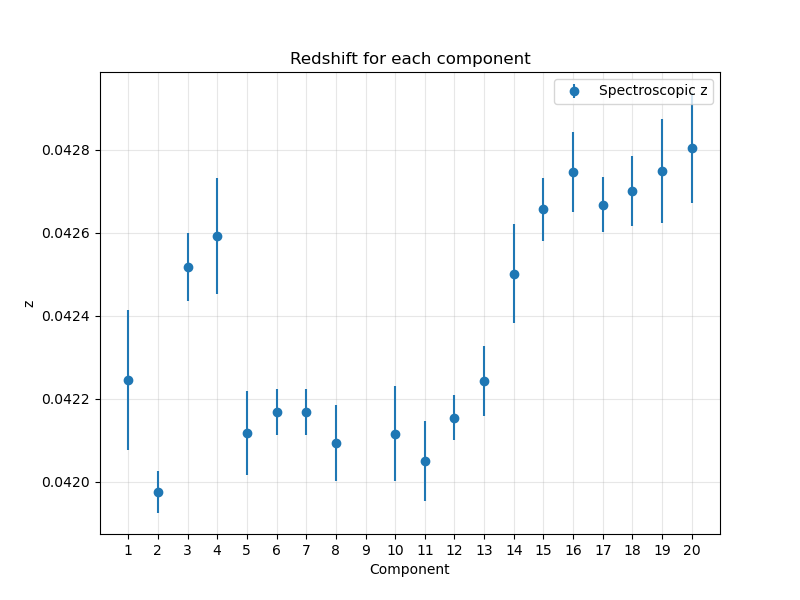

In [44]:
plt.figure(figsize=(8, 6))
comp = np.arange(1, 21, 1)
plt.errorbar(comp, z, z_err, ls='none', marker = 'o', label = 'Spectroscopic z')
plt.xlabel('Component')
plt.ylabel('z')
plt.xticks(comp)
#plt.axhline(0.01505 , color = 'red', label = 'Tabulated z')
plt.title('Redshift for each component')
plt.legend()
plt.savefig('Redshift_grad', bbox_inches='tight')
plt.grid(alpha = 0.3)

z = [z_1_mean, z_2_mean, z_3_mean, z_4_mean, z_5_mean, z_6_mean, z_7_mean, z_8_mean, 0.04263, z_10_mean, z_11_mean, z_12_mean, z_13_mean, z_14_mean, z_15_mean, z_16_mean, z_17_mean, z_18_mean, z_19_mean, z_20_mean]
red_table = np.column_stack((z, z_err))
np.savetxt('redshift_grad.txt', red_table, header='redshift redshift_error', fmt='%.5f',delimiter='\t')

## S/N emission lines 

In [45]:
def SNR_line(wv, wv_line, spectrum): 
    left_region = (wv > wv_line-15)*(wv < wv_line-5) 
    right_region = (wv > wv_line+5)*(wv < wv_line+15) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectrum[mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise
    
def SNR_OIII_line(wv, OIII_1, OIII_2, wv_line, spectrum):
    
    left_region = (wv > OIII_1-15)*(wv < OIII_1-5) 
    right_region = (wv > OIII_2+5)*(wv < OIII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 
    
def SNR_SII_line(wv, SII_1, SII_2, wv_line, spectrum):
    
    left_region = (wv > SII_1-15)*(wv < SII_1-5) 
    right_region = (wv > SII_2+5)*(wv < SII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 

def SNR_HA_NII(wv, NII_1, NII_2, wv_line, spectrum):
    
    left_region = (wv > NII_1-15)*(wv < NII_1-5) 
    right_region = (wv > NII_2+5)*(wv < NII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 

def save_spectral_data(snr, signal, noise, line_name, output_dir='20ext', num_spectra=20):
    
    data = np.concatenate([
        np.array(snr).reshape(-1, 1),
        np.array(signal).reshape(-1, 1),
        np.array(noise).reshape(-1, 1)
    ], axis=1)

    df = pd.DataFrame(
        data, 
        columns=['SNR', 'Signal', 'Noise'],
        index=[f'Spettro_{i+1}' for i in range(num_spectra)]
    )
    
    df_path = os.path.join(output_dir, f'SNR_{line_name}.csv')
    df.to_csv(df_path, float_format='%.3f')
    print(df)
    return df_path

In [46]:
SNR_HB = np.zeros(20)
signal_HB = np.zeros(20)
noise_HB = np.zeros(20)
SNR_SII_1 = np.zeros(20)
signal_SII_1 = np.zeros(20)
noise_SII_1 = np.zeros(20)
SNR_SII_2 = np.zeros(20)
signal_SII_2 = np.zeros(20)
noise_SII_2 = np.zeros(20)
SNR_NII_1 = np.zeros(20)
signal_NII_1 = np.zeros(20)
noise_NII_1 = np.zeros(20)
SNR_NII_2 = np.zeros(20)
signal_NII_2 = np.zeros(20)
noise_NII_2 = np.zeros(20)
SNR_HA = np.zeros(20)
signal_HA = np.zeros(20)
noise_HA = np.zeros(20)
SNR_OIII_1 = np.zeros(20)
signal_OIII_1 = np.zeros(20)
noise_OIII_1 = np.zeros(20)
SNR_OIII_2 = np.zeros(20)
signal_OIII_2 = np.zeros(20)
noise_OIII_2 = np.zeros(20)

for i in range(20):
    if np.isnan(z[i]) == False: 
        l_Hgam = 4340.5*(1+z[i])
        l_HA = 6562.8*(1+z[i])
        l_HB = 4861.3*(1+z[i])
        l_NII_1 = 6548.1*(1+z[i])
        l_NII_2 = 6583.4*(1+z[i])
        l_SII_1 = 6717.0*(1+z[i])
        l_SII_2 = 6731.3*(1+z[i])
        l_OIII_1 = 4958.9*(1+z[i])
        l_OIII_2 = 5006.8*(1+z[i])
        l_He_1 = 5875.6*(1+z[i])
        SNR_HB[i], signal_HB[i], noise_HB[i] = SNR_line(wv, l_HB, spectra[i])
        SNR_SII_1[i], signal_SII_1[i], noise_SII_1[i] = SNR_SII_line(wv, l_SII_1, l_SII_2, l_SII_1, spectra[i])
        SNR_SII_2[i], signal_SII_2[i], noise_SII_2[i] = SNR_SII_line(wv, l_SII_1, l_SII_2, l_SII_2, spectra[i])
        SNR_NII_1[i], signal_NII_1[i], noise_NII_1[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_NII_1, spectra[i])
        SNR_NII_2[i], signal_NII_2[i], noise_NII_2[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_NII_2, spectra[i])
        SNR_HA[i], signal_HA[i], noise_HA[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_HA, spectra[i])
        SNR_OIII_1[i], signal_OIII_1[i], noise_OIII_1[i] = SNR_OIII_line(wv, l_OIII_1, l_OIII_2, l_OIII_1, spectra[i])
        SNR_OIII_2[i], signal_OIII_2[i], noise_OIII_2[i] = SNR_OIII_line(wv, l_OIII_1, l_OIII_2, l_OIII_2, spectra[i])
    else:
        SNR_HB[i] = np.nan
        signal_HB[i] = np.nan
        noise_HB[i] = np.nan
        SNR_SII_1[i] = np.nan 
        signal_SII_1[i] = np.nan 
        noise_SII_1[i] = np.nan 
        SNR_SII_2[i] = np.nan 
        signal_SII_2[i] = np.nan 
        noise_SII_2[i] = np.nan 
        SNR_NII_1[i] = np.nan 
        signal_NII_1[i] = np.nan 
        noise_NII_1[i] = np.nan 
        SNR_NII_2[i] = np.nan 
        signal_NII_2[i] = np.nan 
        noise_NII_2[i] = np.nan 
        SNR_HA[i] = np.nan 
        signal_HA[i] = np.nan 
        noise_HA[i] = np.nan 
        SNR_OIII_1[i] = np.nan 
        signal_OIII_1[i] = np.nan 
        noise_OIII_1[i] = np.nan 
        SNR_OIII_2[i] = np.nan 
        signal_OIII_2[i] = np.nan
        noise_OIII_2[i] = np.nan
        
save_spectral_data(SNR_HB, signal_HB, noise_HB, 'HB')
save_spectral_data(SNR_SII_1, signal_SII_1, noise_SII_1, 'SII_1')
save_spectral_data(SNR_SII_2, signal_SII_2, noise_SII_2, 'SII_2')
save_spectral_data(SNR_NII_1, signal_NII_1, noise_NII_1, 'NII_1')
save_spectral_data(SNR_NII_2, signal_NII_2, noise_NII_2, 'NII_2')
save_spectral_data(SNR_HA, signal_HA, noise_HA, 'HA')
save_spectral_data(SNR_OIII_1, signal_OIII_1, noise_OIII_1, 'OIII_1')
save_spectral_data(SNR_OIII_2, signal_OIII_2, noise_OIII_2, 'OIII_2')

                  SNR     Signal     Noise
Spettro_1    0.430145   0.076232  0.177225
Spettro_2    5.766531   0.997630  0.173004
Spettro_3   43.219409  12.685827  0.293522
Spettro_4   80.127465  34.912781  0.435716
Spettro_5   12.226772   2.163976  0.176987
Spettro_6    4.574258   0.886159  0.193727
Spettro_7    1.285253   0.489906  0.381175
Spettro_8    2.986652   1.248104  0.417894
Spettro_9   -0.532498  -0.457852  0.859820
Spettro_10   4.344569   1.361664  0.313417
Spettro_11   9.693921   3.884018  0.400665
Spettro_12  22.523575  14.660860  0.650912
Spettro_13  32.180513  28.406293  0.882717
Spettro_14  19.048728  18.137971  0.952188
Spettro_15  73.725446  31.248215  0.423846
Spettro_16  12.452670   4.093524  0.328727
Spettro_17   2.995517   0.938417  0.313274
Spettro_18  11.116379   3.140650  0.282525
Spettro_19  17.490615   4.574569  0.261544
Spettro_20   3.808030   1.167456  0.306578
                   SNR     Signal     Noise
Spettro_1     1.352687   0.260406  0.192510
Spettro_2

'20ext\\SNR_OIII_2.csv'

In [ ]:
plt.figure(figsize = (8, 6))
plt.plot(wv, spectra[2])

In [ ]:
l_OIII_2